# Rolling Ambient Reference Level Analysis

This notebook explores how the choice of rolling window size affects the **5th-percentile ambient reference level** computed from broadband hydrophone data stored in S3.

**Goals:**
1. Pull broadband data for several Orcasound hydrophones
2. Compare 5th-percentile ambient reference levels using rolling 1, 2, 3, 4, 5, 6, 7, 8 and 9-day windows
3. Decide on a rolling ambient reference window that requires the least data to reduce small sample noise 
3. Visualize broadband vs. ambient reference for Orcasound Lab over multiple time periods
4. Compare two hydrophones before and after reference adjustment

**Data source:** `s3://acoustic-sandbox/ambient-sound-analysis/data_3.0/broadband/`



In [214]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import datetime as dt
from datetime import timedelta

STORAGE_OPTS = {"aws_region": "us-west-2"}
S3_BASE = "s3://acoustic-sandbox/ambient-sound-analysis/data_3.0"

HYDROPHONES = [
    "orcasound_lab",
    "port_townsend",
    "sunset_bay",
    "andrews_bay",
    "mast_center",
    "point_robinson",
    "north_sjc",
]

BB_SCHEMA = {
    "ind": pl.Datetime("ns"),
    "bb_o": pl.Float64,
    "comm_bb_o": pl.Float64,
    "ship_bb_o": pl.Float64,
    "bb": pl.Float64,
    "comm_bb": pl.Float64,
    "ship_bb": pl.Float64,
}

## Helper functions

In [215]:
def build_bb_paths(hydrophone: str, start: dt.date, end: dt.date) -> list[str]:
    """Build list of daily S3 parquet paths for a hydrophone between start and end dates."""
    paths = []
    d = start
    while d <= end:
        paths.append(
            f"{S3_BASE}/broadband/hydrophone={hydrophone}"
            f"/year={d.year}/month={d.month:02d}/day={d.day:02d}/*.parquet"
        )
        d += timedelta(days=1)
    return paths


def load_broadband(hydrophone: str, start: dt.datetime, end: dt.datetime) -> pl.LazyFrame:
    """Scan broadband parquet data from S3 for a hydrophone and time range."""
    paths = build_bb_paths(hydrophone, start.date(), end.date())
    return (
        pl.scan_parquet(paths, storage_options=STORAGE_OPTS, schema=BB_SCHEMA)
        .filter(pl.col("ind").is_between(start, end))
        .sort("ind")
    )


def rolling_p05_reference(lf: pl.LazyFrame, window_days: int, col: str = "bb_o") -> pl.LazyFrame:
    """
    Compute a rolling 5th-percentile ambient reference level.

    For each second, the reference is the 5th percentile of `col` over the
    preceding `window_days` days (window_days * 86400 rows at 1-second resolution).
    If fewer rows are available, use the partial history instead of returning null.
    """
    window_size = window_days * 86_400
    return lf.with_columns(
        pl.col(col)
        .rolling_quantile(0.05, window_size=window_size, min_samples=1)
        .alias(f"ref_p05_{window_days}d")
    )


def compute_daily_p05(df: pl.DataFrame, col: str = "bb_o") -> pl.DataFrame:
    """Compute daily 5th-percentile from a collected DataFrame."""
    return (
        df.with_columns(pl.col("ind").dt.date().alias("date"))
        .group_by("date")
        .agg(pl.col(col).quantile(0.05).alias("daily_p05"))
        .sort("date")
    )

## 1. Load broadband data for all hydrophones

We pull the most recent 14 days of data so we have enough history for the 9-day rolling window plus several days of usable reference values.

In [216]:
# Date range — 10 days ending yesterday (today's data may be incomplete)
END = dt.datetime(2026, 3, 13, 23, 59, 59)
START = END - timedelta(days=14)

print(f"Loading broadband data from {START} to {END}")

# Load data for each hydrophone
bb_data: dict[str, pl.DataFrame] = {}
for hp in HYDROPHONES:
    try:
        lf = load_broadband(hp, START, END)
        df = lf.collect()
        bb_data[hp] = df
        print(f"  {hp}: {len(df):,} rows, {df['ind'].min()} → {df['ind'].max()}")
    except Exception as e:
        print(f"  {hp}: FAILED — {e}")

print(f"\nLoaded {len(bb_data)} hydrophones successfully.")

Loading broadband data from 2026-02-27 23:59:59 to 2026-03-13 23:59:59
  orcasound_lab: 1,060,988 rows, 2026-03-01 00:00:00 → 2026-03-13 23:59:59
  port_townsend: 523,244 rows, 2026-03-08 18:22:37 → 2026-03-13 23:58:17
  sunset_bay: 281,333 rows, 2026-03-08 18:22:32 → 2026-03-11 21:04:11
  andrews_bay: 524,039 rows, 2026-03-08 18:22:42 → 2026-03-13 23:58:30
  mast_center: 521,757 rows, 2026-03-08 18:22:32 → 2026-03-13 23:59:59
  point_robinson: 519,798 rows, 2026-03-08 18:22:53 → 2026-03-13 23:58:26
  north_sjc: 520,630 rows, 2026-03-08 18:22:55 → 2026-03-13 23:58:14

Loaded 7 hydrophones successfully.


In [217]:
bb_data['orcasound_lab']

ind,bb_o,comm_bb_o,ship_bb_o,bb,comm_bb,ship_bb
datetime[ns],f64,f64,f64,f64,f64,f64
2026-03-01 00:00:00,-55.76,-57.27,-65.16,-0.065,6.081,-7.875
2026-03-01 00:00:01,-52.544652,-54.123478,-62.064514,3.150348,9.227522,-4.779514
2026-03-01 00:00:02,-53.209436,-54.813731,-63.493913,2.485564,8.537269,-6.208913
2026-03-01 00:00:03,-53.04,-54.629816,-63.867053,2.655,8.721184,-6.582053
2026-03-01 00:00:04,-52.731866,-54.719896,-60.585706,2.963134,8.631104,-3.300706
…,…,…,…,…,…,…
2026-03-13 23:59:57,-32.973201,-36.904767,-35.83968,21.712792,23.74182,23.066741
2026-03-13 23:59:58,-32.754514,-36.885396,-35.432808,21.931479,23.761191,23.473613
2026-03-13 23:59:58,-32.754514,-36.885396,-35.432808,21.931479,23.761191,23.473613


## 2. Compare rolling 5th-percentile reference windows (1, 2, 3, 4, 5, 6, 7, 8, 9 days)

For the Orcasound Lab, compute the 5th-percentile of `bb_o` over rolling windows of different sizes and compare how the reference level changes.

In [218]:
def add_rolling_refs(
    df: pl.DataFrame,
    col: str = "bb_o",
    window_days: list[int] | None = None,
    quantile: float = 0.05,
    require_full_window: bool = False,
) -> pl.DataFrame:
    """Add rolling quantile reference columns for each window size."""
    if window_days is None:
        window_days = [1, 2, 3, 4, 5, 6, 7, 8, 9]

    result = df.lazy()
    for w in window_days:
        window_size = w * 86_400
        min_periods = window_size if require_full_window else 1

        result = result.with_columns(
            pl.col(col)
            .rolling_quantile(quantile, window_size=window_size, min_periods=min_periods)
            .alias(f"ref_p{int(quantile * 100):02d}_{w}d")
        )
    return result.collect()

def add_daily_refs(
    df: pl.DataFrame,
    col: str = "bb_o",
    window_days: list[int] | None = None,
    quantile: float = 0.05,
) -> pl.DataFrame:
    if window_days is None:
        window_days = [1, 2, 3, 4, 5, 6, 7, 8, 9]

    dates = df.select(pl.col("ind").dt.date().unique().alias("date")).sort("date")
    result = dates

    for w in window_days:
        refs = []
        for d in dates["date"]:
            start = d - timedelta(days=w)
            window_data = df.filter(
                (pl.col("ind").dt.date() >= start) & (pl.col("ind").dt.date() < d)
            )
            refs.append(window_data[col].quantile(quantile) if len(window_data) > 0 else None)
        result = result.with_columns(
            pl.Series(f"ref_p{int(quantile * 100):02d}_{w}d", refs)
        )

    print(result.columns)  # should show date + one ref col per window
    return result


# Compute rolling references for all hydrophones
bb_with_refs: dict[str, pl.DataFrame] = {}
for hp, df in bb_data.items():
    print(f"Computing rolling references for {hp}...")
    bb_with_refs[hp] = add_rolling_refs(df, require_full_window=False)

bb_with_refs_full_window: dict[str, pl.DataFrame] = {}
for hp, df in bb_data.items():
    print(f"Computing rolling references for {hp}...")
    # bb_with_refs_full_window[hp] = add_rolling_refs(df, require_full_window=True)
    bb_with_refs_full_window[hp] = add_daily_refs(df)



print("Done.")

Computing rolling references for orcasound_lab...


/var/folders/63/jzv4h4hj37j3wl3_r5y5828h0000gn/T/ipykernel_24245/3740007422.py:19: DeprecationWarning: the argument `min_periods` for `Expr.rolling_quantile` is deprecated. It was renamed to `min_samples` in version 1.21.0.
  .rolling_quantile(quantile, window_size=window_size, min_periods=min_periods)


Computing rolling references for port_townsend...
Computing rolling references for sunset_bay...
Computing rolling references for andrews_bay...
Computing rolling references for mast_center...
Computing rolling references for point_robinson...
Computing rolling references for north_sjc...
Computing rolling references for orcasound_lab...
['date', 'ref_p05_1d', 'ref_p05_2d', 'ref_p05_3d', 'ref_p05_4d', 'ref_p05_5d', 'ref_p05_6d', 'ref_p05_7d', 'ref_p05_8d', 'ref_p05_9d']
Computing rolling references for port_townsend...
['date', 'ref_p05_1d', 'ref_p05_2d', 'ref_p05_3d', 'ref_p05_4d', 'ref_p05_5d', 'ref_p05_6d', 'ref_p05_7d', 'ref_p05_8d', 'ref_p05_9d']
Computing rolling references for sunset_bay...
['date', 'ref_p05_1d', 'ref_p05_2d', 'ref_p05_3d', 'ref_p05_4d', 'ref_p05_5d', 'ref_p05_6d', 'ref_p05_7d', 'ref_p05_8d', 'ref_p05_9d']
Computing rolling references for andrews_bay...
['date', 'ref_p05_1d', 'ref_p05_2d', 'ref_p05_3d', 'ref_p05_4d', 'ref_p05_5d', 'ref_p05_6d', 'ref_p05_7d', 're

In [219]:
bb_with_refs_full_window['orcasound_lab']

date,ref_p05_1d,ref_p05_2d,ref_p05_3d,ref_p05_4d,ref_p05_5d,ref_p05_6d,ref_p05_7d,ref_p05_8d,ref_p05_9d
date,f64,f64,f64,f64,f64,f64,f64,f64,f64
2026-03-01,null,null,null,null,null,null,null,null,null
2026-03-02,-60.414238,-60.414238,-60.414238,-60.414238,-60.414238,-60.414238,-60.414238,-60.414238,-60.414238
2026-03-03,-59.163344,-59.803838,-59.803838,-59.803838,-59.803838,-59.803838,-59.803838,-59.803838,-59.803838
2026-03-04,-59.679586,-59.389896,-59.757053,-59.757053,-59.757053,-59.757053,-59.757053,-59.757053,-59.757053
2026-03-05,-56.716271,-58.698849,-58.907474,-59.335396,-59.335396,-59.335396,-59.335396,-59.335396,-59.335396
…,…,…,…,…,…,…,…,…,…
2026-03-09,-55.728342,-54.559712,-54.315219,-54.750123,-55.327749,-56.657744,-57.414652,-57.795655,-57.795655
2026-03-10,-50.05213,-54.524767,-53.525396,-53.619988,-54.204652,-54.875705,-56.201311,-57.073961,-57.484997
2026-03-11,-51.413913,-50.82741,-53.467744,-52.82883,-53.133201,-53.76098,-54.419625,-55.789954,-56.738055


### Plot: Rolling reference comparison for each hydrophone

Shows how the 5th-percentile reference level varies with window size. Shorter windows track recent conditions more closely; longer windows provide a more stable baseline.

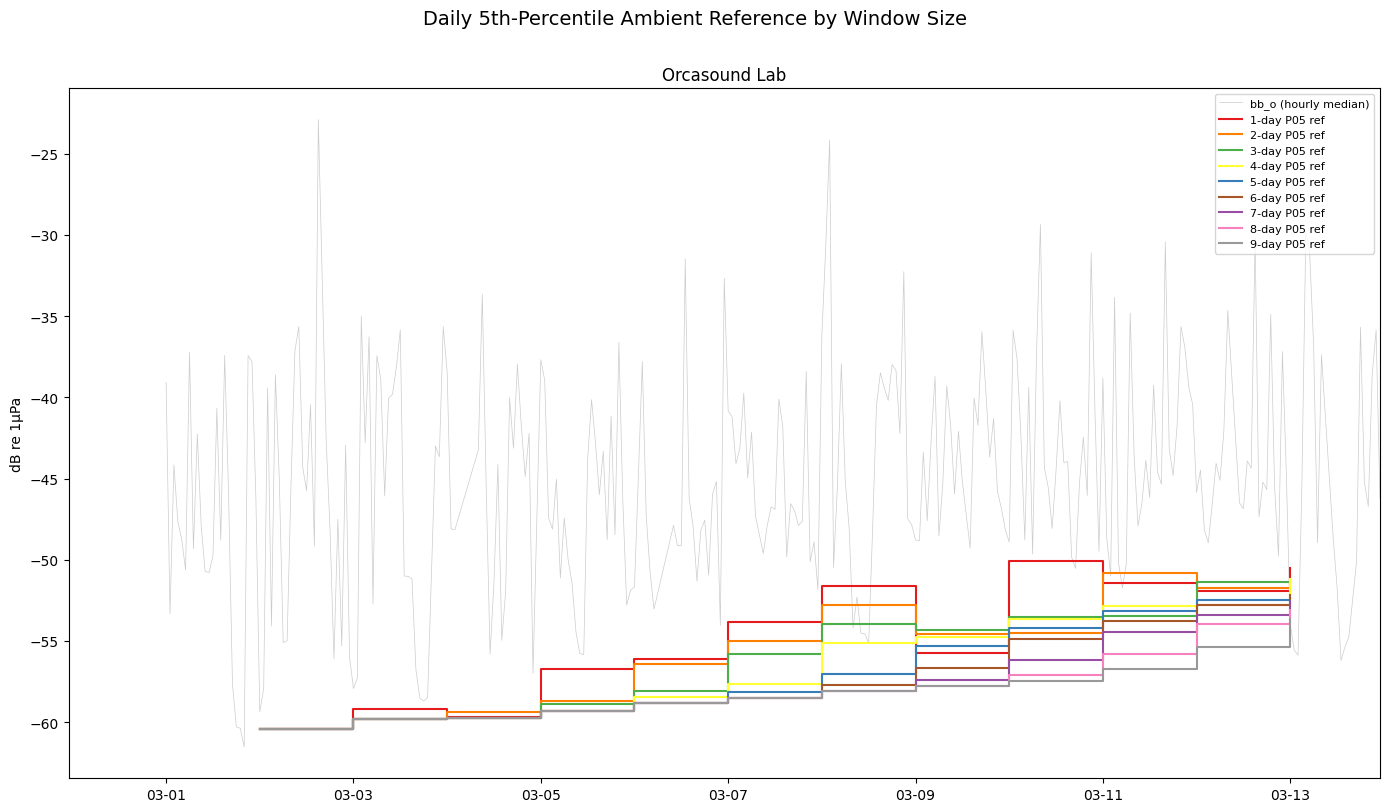

In [220]:
colors = {1: "#e41a1c", 2: "#ff7f00", 3: "#4daf4a", 4: "#ffff33", 5: "#377eb8", 6: "#a65628", 7: "#984ea3", 8: "#f781bf", 9: "#999999"}

WINDOW_DAYS = [1, 2, 3, 4, 5, 6, 7, 8, 9]

fig, ax = plt.subplots(1, 1, figsize=(14, 8))

raw = bb_data['orcasound_lab']
refs = bb_with_refs_full_window['orcasound_lab']

# Downsample raw data to hourly medians
hourly = (
    raw.lazy()
    .with_columns(pl.col("ind").dt.truncate("1h").alias("hour"))
    .group_by("hour")
    .agg(pl.col("bb_o").median().alias("bb_o_med"))
    .sort("hour")
    .collect()
)

ts = hourly["hour"].to_numpy()
end = ts.max()
start = end - np.timedelta64(14, "D")

ax.plot(ts, hourly["bb_o_med"].to_numpy(), color="gray", alpha=0.4, linewidth=0.5, label="bb_o (hourly median)")

# Plot daily refs as step lines
ref_dates = refs["date"].to_numpy()
for w in WINDOW_DAYS:
    col = f"ref_p05_{w}d"
    ax.step(ref_dates, refs[col].to_numpy(), where="post", color=colors[w], linewidth=1.5, label=f"{w}-day P05 ref")

ax.set_xlim(start, end)
ax.set_ylabel("dB re 1µPa")
ax.set_title("Orcasound Lab")
ax.legend(loc="upper right", fontsize=8)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d"))

fig.suptitle("Daily 5th-Percentile Ambient Reference by Window Size", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### Summary table: Reference level statistics by window size

For Orcasound Lab, show the mean and standard deviation of the rolling reference for each window size. Longer windows should show lower variability.

In [221]:
df = bb_with_refs_full_window['orcasound_lab']
df = df.filter(pl.col("date") >= start)

rows = []
for w in WINDOW_DAYS:
    col = f"ref_p05_{w}d"
    vals = df[col].drop_nulls()
    if len(vals) > 0:
        rows.append({
            "hydrophone": 'orcasound_lab',
            "window_days": w,
            "mean_ref_dB": round(vals.mean(), 2),
            "std_ref_dB": round(vals.std(), 3),
            "min_ref_dB": round(vals.min(), 2),
            "max_ref_dB": round(vals.max(), 2),
        })

ref_summary = pl.DataFrame(rows)
ref_summary

hydrophone,window_days,mean_ref_dB,std_ref_dB,min_ref_dB,max_ref_dB
str,i64,f64,f64,f64,f64
"""orcasound_lab""",1,-54.76,3.725,-60.41,-50.05
"""orcasound_lab""",2,-55.47,3.453,-60.41,-50.83
"""orcasound_lab""",3,-55.9,3.339,-60.41,-51.37
"""orcasound_lab""",4,-56.3,3.279,-60.41,-51.18
"""orcasound_lab""",5,-56.73,3.074,-60.41,-52.34
"""orcasound_lab""",6,-57.05,2.935,-60.41,-52.17
"""orcasound_lab""",7,-57.39,2.663,-60.41,-52.51
"""orcasound_lab""",8,-57.71,2.327,-60.41,-53.12
"""orcasound_lab""",9,-57.98,1.965,-60.41,-53.64


# Plot Standard Deviation for the different window sizes to see if there is a clear elbow point where variability change slows down 

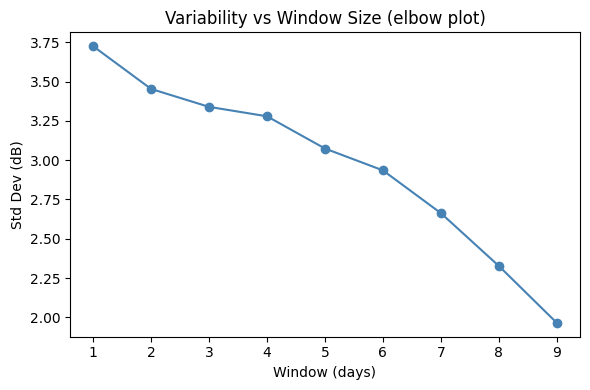

In [222]:
stds = ref_summary.sort("window_days")["std_ref_dB"].to_list()
windows = ref_summary.sort("window_days")["window_days"].to_list()

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(windows, stds, "o-", color="steelblue")
ax.set_xlabel("Window (days)")
ax.set_ylabel("Std Dev (dB)")
ax.set_title("Variability vs Window Size (elbow plot)")
plt.tight_layout()
plt.show()

# Calculate the second derivatives of the standard deviation to quantify the rate in reduction of variability 
The second derivative of standard deviation with respect to window size oscillates in sign for shorter windows (2–5 days), suggesting the rate of variability reduction  is unstable. Beginning at the 6-day window, the second derivative remains consistently negative, indicating that each additional day yields a diminishing but steady reduction in variability. The magnitude also decreases toward zero (−0.133 -> −0.064 -> −0.026), confirming the reference level is flattening as window size increases.

However, eliminating all variability in the reference is undesirablem true ambient variability exists due to changing oceanographic conditions, vessel traffic patterns, and potential hydrophone drift. The reference should be stable enough to serve as a baseline but responsive enough to reflect genuine shifts in ambient conditions.

A 7-day window balances these considerations: it sits past the point where variability reduction stabilizes (6+ days) while preserving sensitivity to real environmental change, as evidenced by the second derivative still being nonzero (−0.064).

In [223]:

w = np.array(windows)
s = np.array(stds)

# Second derivative
dds = np.diff(ds) / np.diff(w[:-1])

for i in range(len(dds)):
    print(f"{windows[i+1]}d: d²std/dw² = {dds[i]:.4f}")

2d: d²std/dw² = 0.1580
3d: d²std/dw² = 0.0540
4d: d²std/dw² = -0.1450
5d: d²std/dw² = 0.0660
6d: d²std/dw² = -0.1330
7d: d²std/dw² = -0.0640
8d: d²std/dw² = -0.0260


## 3. Orcasound Lab: Broadband vs. ambient reference over 1, 3, 5, and 7 days

Visualize the raw broadband signal (`bb_o`) alongside the 7-day rolling 5th-percentile reference for different time windows. The reference acts as a "floor" that the broadband rarely dips below.

## 4. Two-hydrophone comparison: Raw vs. reference-adjusted

Compare Orcasound Lab and Mast Center side by side:
- **Left column:** Raw broadband (`bb_o`): different baseline levels make direct comparison misleading
- **Right column:** Reference-adjusted (`bb_o - ref_p05_7d`): subtracting each site's own ambient floor normalizes them to a common baseline, making the comparison more apples-to-apples

In [224]:


HP_A = "orcasound_lab"
HP_B = "mast_center"

raw_a = bb_data[HP_A]
raw_b = bb_data[HP_B]
refs_a = bb_with_refs_full_window[HP_A]
refs_b = bb_with_refs_full_window[HP_B]

# Join daily ref onto raw data by date
df_a = raw_a.with_columns(pl.col("ind").dt.date().alias("date")).join(
    refs_a.select("date", "ref_p05_7d"), on="date", how="left"
).filter(pl.col("ref_p05_7d").is_not_null())

df_b = raw_b.with_columns(pl.col("ind").dt.date().alias("date")).join(
    refs_b.select("date", "ref_p05_7d"), on="date", how="left"
).filter(pl.col("ref_p05_7d").is_not_null())

# Find overlapping time range
overlap_start = max(df_a["ind"].min(), df_b["ind"].min())
overlap_end = min(df_a["ind"].max(), df_b["ind"].max())
view_start = overlap_end - timedelta(days=2)

df_a = df_a.filter(pl.col("ind").is_between(view_start, overlap_end))
df_b = df_b.filter(pl.col("ind").is_between(view_start, overlap_end))

def rolling_window_summary(df, rolling_window="30m"):
    return (
        df.lazy()
        .with_columns([
            pl.col("ind").dt.truncate("1m").alias("minute"),
            (pl.col("bb_o") - pl.col("ref_p05_7d")).alias("bb_adjusted"),
        ])
        .group_by("minute")
        .agg([
            pl.col("bb_o").median().alias("bb_o_med"),
            pl.col("ref_p05_7d").median().alias("ref_med"),
            pl.col("bb_adjusted").median().alias("bb_adj_med"),
        ])
        .sort("minute")
        .with_columns([
            pl.col("bb_o_med")
              .rolling_median_by("minute", window_size=rolling_window)
              .alias("bb_o_med_rolling"),
            pl.col("ref_med")
              .rolling_median_by("minute", window_size=rolling_window)
              .alias("ref_med_rolling"),
            pl.col("bb_adj_med")
              .rolling_median_by("minute", window_size=rolling_window)
              .alias("bb_adj_med_rolling"),
        ])
        .collect()
    )

ha = rolling_window_summary(df_a)
hb = rolling_window_summary(df_b)

print(f"Comparing {HP_A} vs {HP_B}")
print(f"Overlap window: {view_start} → {overlap_end}")

Comparing orcasound_lab vs mast_center
Overlap window: 2026-03-11 23:59:59 → 2026-03-13 23:59:59


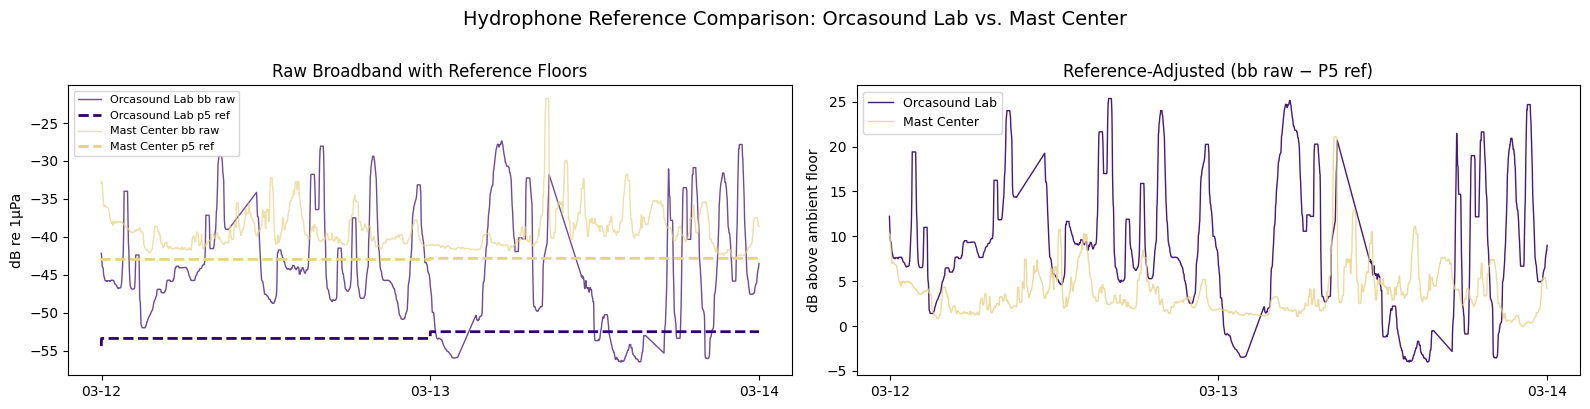

In [225]:
import matplotlib.dates as mdates

fig, axes = plt.subplots(1, 2, figsize=(16, 4), sharey="col")

label_a = HP_A.replace("_", " ").title()
label_b = HP_B.replace("_", " ").title()

# Top-right: Reference-adjusted — both hydrophones
axes[1].plot(ha["minute"].to_numpy(), ha["bb_adj_med_rolling"].to_numpy(),
                color="#32006e", linewidth=1, label=label_a, alpha=0.9)
axes[1].plot(hb["minute"].to_numpy(), hb["bb_adj_med_rolling"].to_numpy(),
                color="#e8d382", linewidth=1, label=label_b, alpha=0.8)
axes[1].set_title("Reference-Adjusted (bb raw − P5 ref)")
axes[1].xaxis.set_major_locator(mdates.DayLocator())
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
axes[1].set_ylabel("dB above ambient floor")
axes[1].legend(fontsize=9)

# Bottom-left: Raw with reference lines
axes[0].plot(ha["minute"].to_numpy(), ha["bb_o_med_rolling"].to_numpy(),
                color="#32006e", linewidth=1, alpha=0.7, label=f"{label_a} bb raw")
axes[0].plot(ha["minute"].to_numpy(), ha["ref_med"].to_numpy(),
                color="#32006e", linewidth=2, linestyle="--", label=f"{label_a} p5 ref")
axes[0].plot(hb["minute"].to_numpy(), hb["bb_o_med_rolling"].to_numpy(),
                color="#e8d382", linewidth=1, alpha=0.7, label=f"{label_b} bb raw")
axes[0].plot(hb["minute"].to_numpy(), hb["ref_med"].to_numpy(),
                color="#e8d382", linewidth=2, linestyle="--", label=f"{label_b} p5 ref")
axes[0].xaxis.set_major_locator(mdates.DayLocator())
axes[0].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
axes[0].set_title("Raw Broadband with Reference Floors")
axes[0].set_ylabel("dB re 1µPa")
axes[0].legend(fontsize=8)

for ax in axes.flat:
    if hasattr(ax, "xaxis") and ax.get_xticklabels():
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d"))

fig.suptitle(f"Hydrophone Reference Comparison: {label_a} vs. {label_b}", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## Key takeaways

- **Shorter rolling windows** (1–2 days) produce a reference that tracks recent noise conditions closely, but can be volatile — a quiet evening can shift the reference significantly
- **Longer rolling windows** (5–9 days) produce a more stable ambient floor that smooths over diurnal and weather-driven variability
- **The 7-day P05 reference** provides a stable baseline that balances reducing short window varibility while allowing for capture change in medium term environment and equipment changes. 
- **Reference adjustment normalizes cross-site comparison**: raw broadband levels differ across hydrophones due to equipment, placement, and local ambient conditions. Subtracting each site's own P05 reference puts them on a common "dB above ambient floor" scale, enabling more meaningful comparison of noise events and trends